# 🔍 Credit Card Fraud Detection System

**Dataset:** 284,807 transactions | **Fraud cases:** 492 (0.17%)  
**Approach:** Isolation Forest (anomaly detection) + XGBoost with SMOTE (classification)  
**Metrics:** F1-Score, AUC-ROC, Precision-Recall Curve

---

## 1. Setup & Imports

In [1]:
!pip install imbalanced-learn xgboost --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & ML
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, ConfusionMatrixDisplay
)

# Models
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = {'Legitimate': '#2ecc71', 'Fraud': '#e74c3c'}

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load & Explore Data

In [4]:
# ─── Load dataset ───────────────────────────────────────────────────────────
df = pd.read_csv("C:\\Users\\DELL\\OneDrive\\Desktop\\codec\\creditcard.csv")

print('='*55)
print(f'  Dataset Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Memory Usage      : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'  Missing Values    : {df.isnull().sum().sum()}')
print('='*55)
print()

# Class distribution
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct   = fraud_count / len(df) * 100
print(f'  Legitimate Txns   : {legit_count:,} ({100 - fraud_pct:.2f}%)')
print(f'  Fraudulent Txns   : {fraud_count:,} ({fraud_pct:.4f}%)')
print(f'  Imbalance Ratio   : {legit_count // fraud_count}:1')

df.head()

  Dataset Shape     : 284,807 rows × 31 columns
  Memory Usage      : 70.6 MB
  Missing Values    : 0

  Legitimate Txns   : 284,315 (99.83%)
  Fraudulent Txns   : 492 (0.1727%)
  Imbalance Ratio   : 577:1


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Statistical summary by class
df.groupby('Class')[['Amount', 'Time']].describe().round(2)

Amount                                                          Time  \
          count    mean     std  min   25%    50%     75%       max     count   
Class                                                                           
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16  284315.0   
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87     492.0   

                                                                        
           mean       std    min      25%      50%       75%       max  
Class                                                                   
0      94838.20  47484.02    0.0  54230.0  84711.0  139333.0  172792.0  
1      80746.81  47835.37  406.0  41241.5  75568.5  128483.0  170348.0

## 3. Exploratory Data Analysis

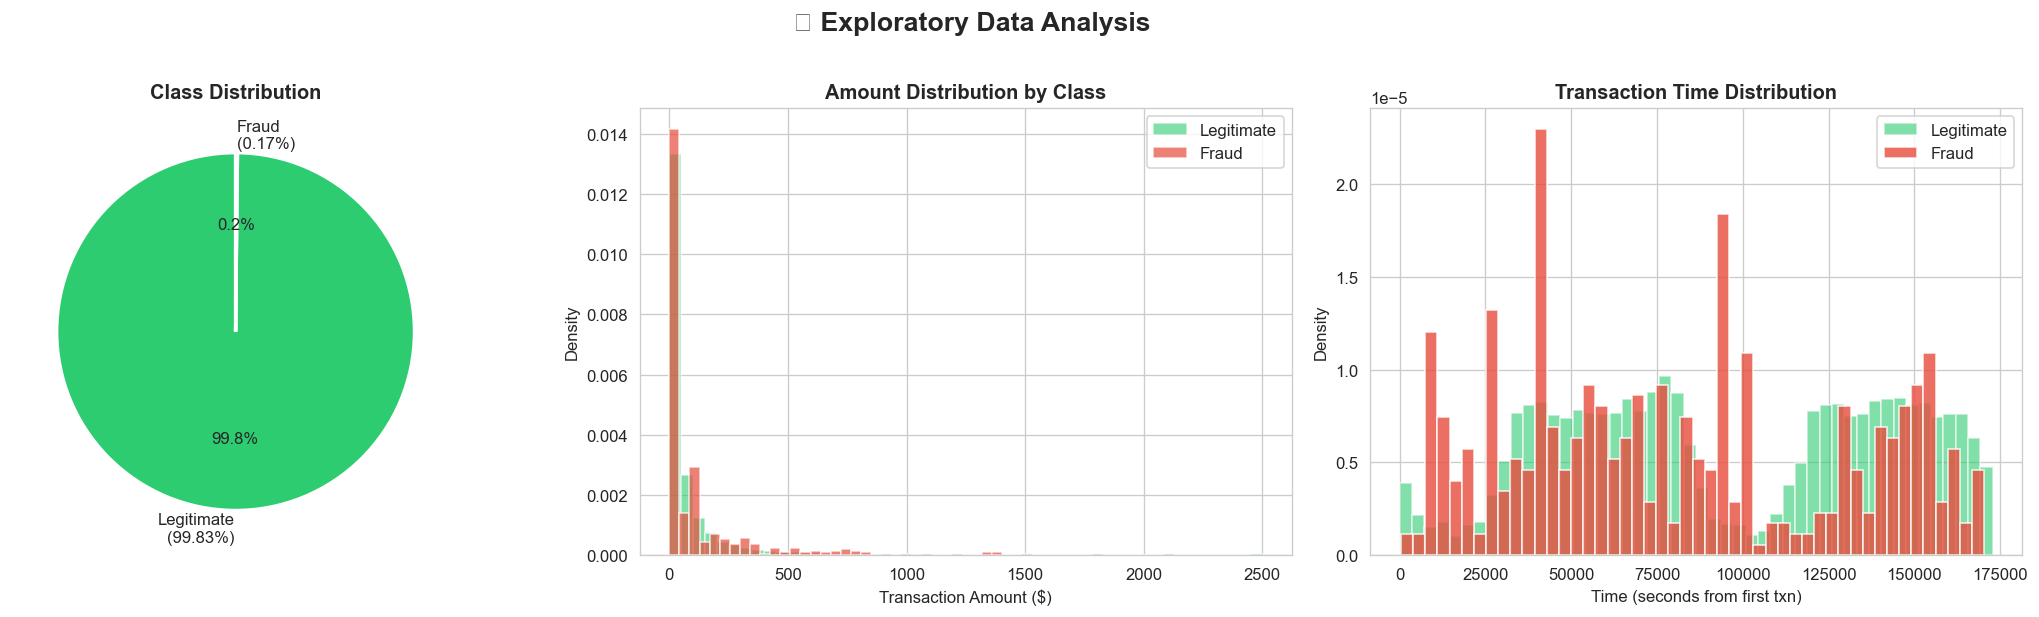

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Class Distribution ──────────────────────────────────────────────
ax = axes[0]
counts = [legit_count, fraud_count]
labels = ['Legitimate\n(99.83%)', 'Fraud\n(0.17%)']
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
ax.set_title('Class Distribution', fontweight='bold')

# ── Plot 2: Transaction Amount Distribution ──────────────────────────────────
ax = axes[1]
df[df['Class'] == 0]['Amount'].clip(upper=2500).plot(
    kind='hist', bins=50, ax=ax, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
df[df['Class'] == 1]['Amount'].clip(upper=2500).plot(
    kind='hist', bins=50, ax=ax, alpha=0.7, color='#e74c3c', label='Fraud', density=True)
ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Density')
ax.set_title('Amount Distribution by Class', fontweight='bold')
ax.legend()

# ── Plot 3: Transaction Time ─────────────────────────────────────────────────
ax = axes[2]
df[df['Class'] == 0]['Time'].plot(
    kind='hist', bins=48, ax=ax, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
df[df['Class'] == 1]['Time'].plot(
    kind='hist', bins=48, ax=ax, alpha=0.8, color='#e74c3c', label='Fraud', density=True)
ax.set_xlabel('Time (seconds from first txn)')
ax.set_ylabel('Density')
ax.set_title('Transaction Time Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()

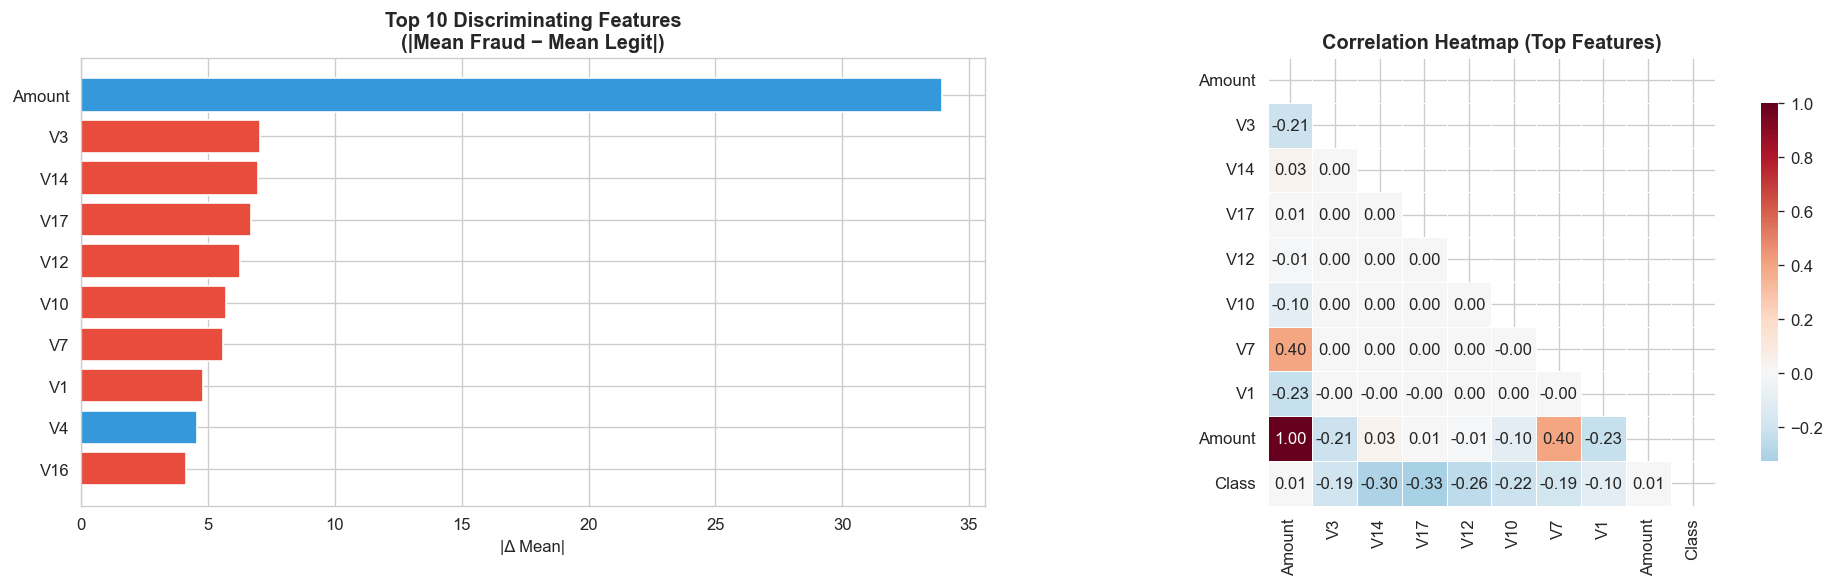

In [7]:
# ── Top discriminating features (mean difference fraud vs legit) ─────────────
fraud_mean  = df[df['Class'] == 1].mean()
legit_mean  = df[df['Class'] == 0].mean()
diff = (fraud_mean - legit_mean).drop(['Class', 'Time'])
diff_sorted = diff.abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 feature mean difference
top10 = diff_sorted.head(10)
colors_bar = ['#e74c3c' if diff[f] < 0 else '#3498db' for f in top10.index]
axes[0].barh(top10.index[::-1], top10.values[::-1], color=colors_bar[::-1])
axes[0].set_title('Top 10 Discriminating Features\n(|Mean Fraud − Mean Legit|)', fontweight='bold')
axes[0].set_xlabel('|Δ Mean|')

# Correlation heatmap (fraud-only, top features)
top_feats = list(top10.index[:8]) + ['Amount', 'Class']
corr = df[top_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap (Top Features)', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

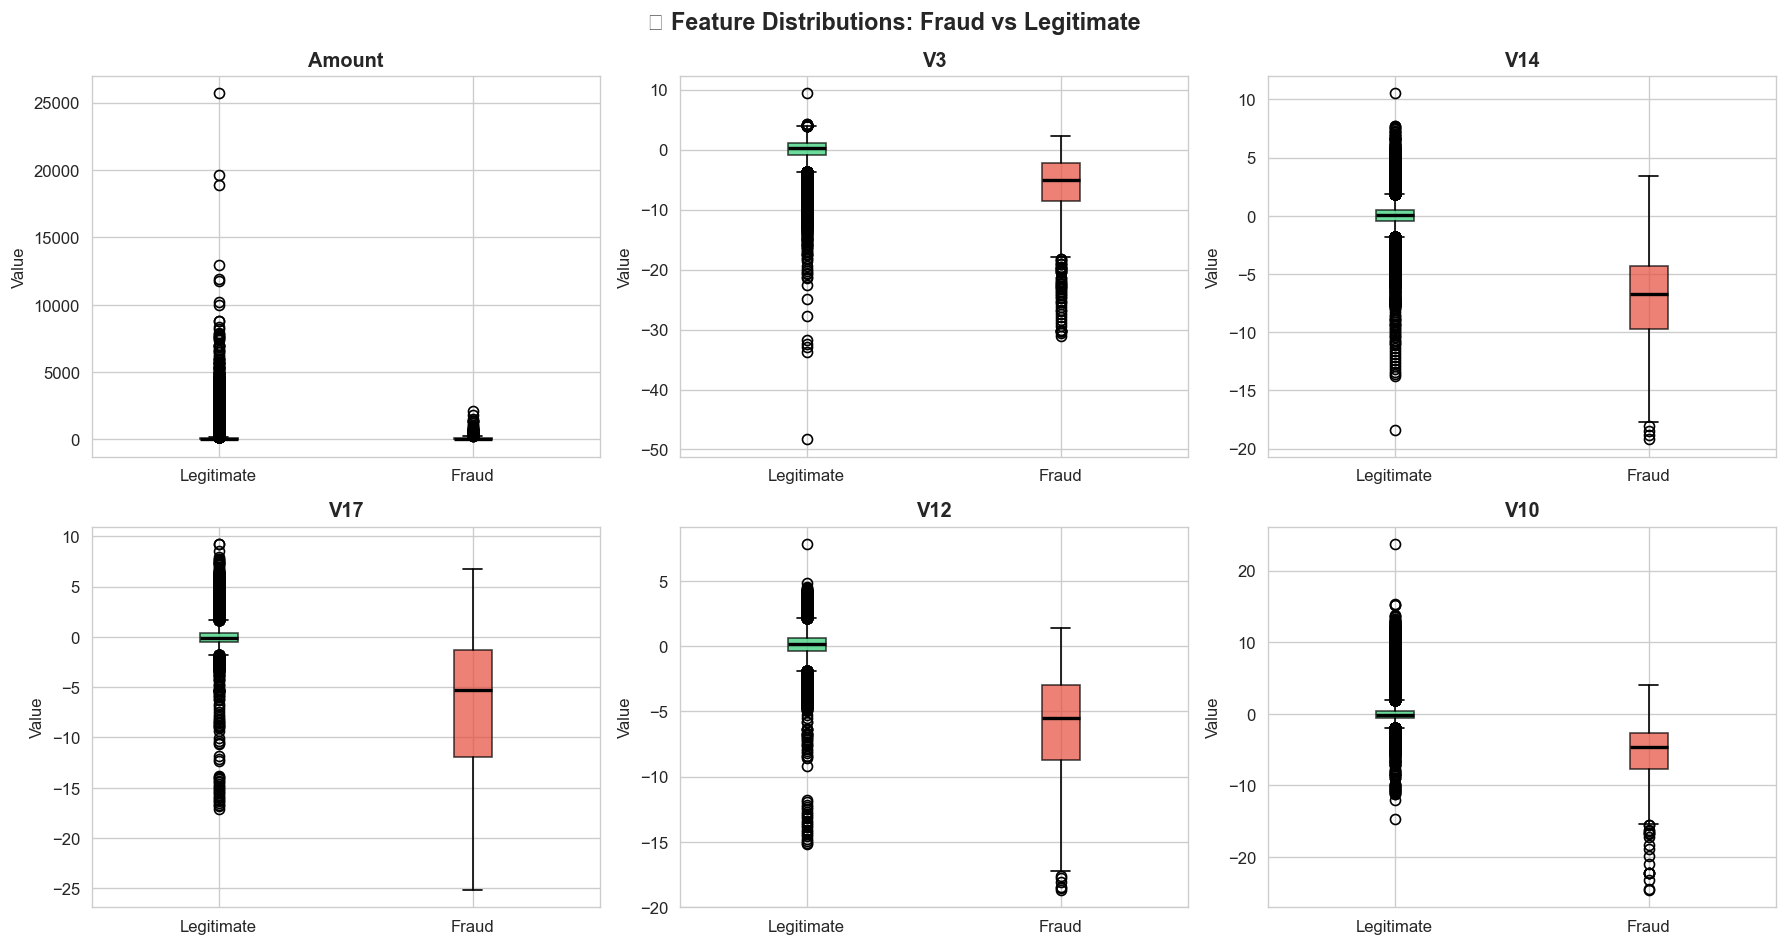

In [8]:
# ── Box plots for top 6 features ────────────────────────────────────────────
top6 = list(diff_sorted.head(6).index)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('📦 Feature Distributions: Fraud vs Legitimate', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top6):
    data_legit = df[df['Class'] == 0][feat]
    data_fraud = df[df['Class'] == 1][feat]
    ax.boxplot(
        [data_legit, data_fraud],
        labels=['Legitimate', 'Fraud'],
        patch_artist=True,
        boxprops={'alpha': 0.7},
        medianprops={'color': 'black', 'linewidth': 2}
    )
    boxes = ax.patches
    if len(boxes) >= 2:
        boxes[0].set_facecolor('#2ecc71')
        boxes[1].set_facecolor('#e74c3c')
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('feature_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Data Preprocessing

In [9]:
# ── Feature Engineering ──────────────────────────────────────────────────────
df_proc = df.copy()

# Scale Amount and Time (V1-V28 are already PCA'd)
rs = RobustScaler()  # Robust to outliers
df_proc['Amount_scaled'] = rs.fit_transform(df_proc[['Amount']])
df_proc['Time_scaled']   = rs.fit_transform(df_proc[['Time']])

# Hour of day feature
df_proc['Hour'] = (df_proc['Time'] % 86400) // 3600

# Drop original unscaled columns
df_proc.drop(columns=['Amount', 'Time'], inplace=True)

print('✅ Features engineered')
print(f'   Final feature count: {df_proc.shape[1] - 1}')

# ── Train/Test Split (stratified) ───────────────────────────────────────────
X = df_proc.drop('Class', axis=1)
y = df_proc['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'\n   Train set: {X_train.shape[0]:,} | Fraud: {y_train.sum():,}')
print(f'   Test set : {X_test.shape[0]:,}  | Fraud: {y_test.sum():,}')

✅ Features engineered
   Final feature count: 31

   Train set: 227,845 | Fraud: 394
   Test set : 56,962  | Fraud: 98


  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py",

Before SMOTE: {0: np.int64(227451), 1: np.int64(394)}
After  SMOTE: {0: np.int64(227451), 1: np.int64(227451)}


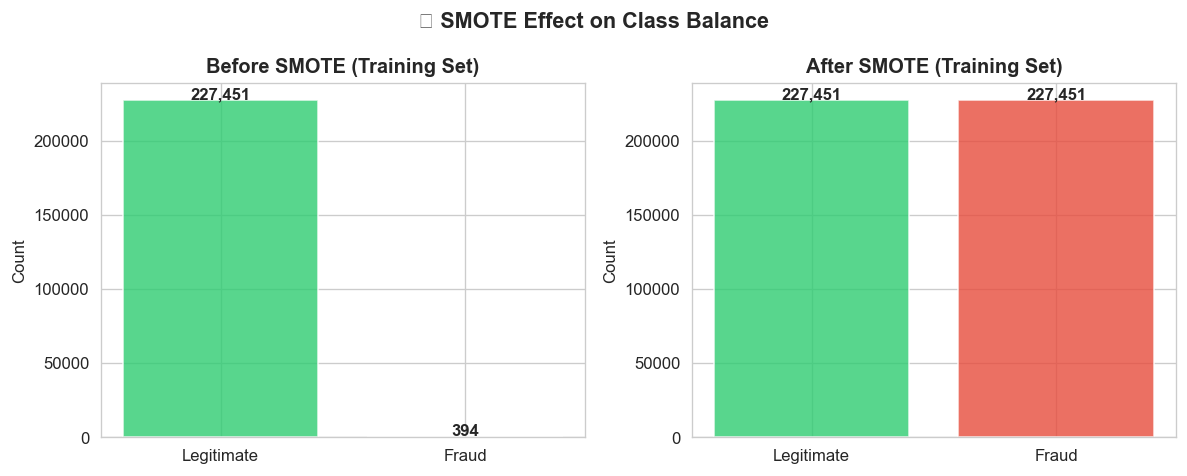

In [10]:
# ── SMOTE: Synthetic Minority Over-sampling ──────────────────────────────────
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))
print('After  SMOTE:', dict(pd.Series(y_train_smote).value_counts()))

# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_data, title) in zip(axes, [
    (y_train, 'Before SMOTE (Training Set)'),
    (y_train_smote, 'After SMOTE (Training Set)')
]):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['Legitimate', 'Fraud'], counts.values,
                  color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='white')
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{cnt:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('🔧 SMOTE Effect on Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_balance.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Model 1: Isolation Forest (Anomaly Detection)

In [11]:
print('🌲 Training Isolation Forest...')

# Contamination = expected fraud rate
contamination = y_train.mean()

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_samples='auto',
    random_state=SEED,
    n_jobs=-1
)

iso_forest.fit(X_train)

# Predictions: IsolationForest returns -1 (anomaly) / 1 (normal)
iso_raw   = iso_forest.predict(X_test)
iso_pred  = np.where(iso_raw == -1, 1, 0)  # Convert to 0/1
iso_score = -iso_forest.decision_function(X_test)  # Higher = more anomalous

# ── Metrics ─────────────────────────────────────────────────────────────────
print()
print('='*55)
print('  ISOLATION FOREST — RESULTS')
print('='*55)
print(classification_report(y_test, iso_pred, target_names=['Legitimate', 'Fraud']))

iso_f1  = f1_score(y_test, iso_pred)
iso_auc = roc_auc_score(y_test, iso_score)
iso_ap  = average_precision_score(y_test, iso_score)

print(f'  F1-Score   : {iso_f1:.4f}')
print(f'  AUC-ROC    : {iso_auc:.4f}')
print(f'  Avg Precis : {iso_ap:.4f}')

🌲 Training Isolation Forest...

  ISOLATION FOREST — RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.25      0.27      0.26        98

    accuracy                           1.00     56962
   macro avg       0.62      0.63      0.63     56962
weighted avg       1.00      1.00      1.00     56962

  F1-Score   : 0.2574
  AUC-ROC    : 0.9458
  Avg Precis : 0.1625


## 6. Model 2: XGBoost with SMOTE (Classification)

In [12]:
print('⚡ Training XGBoost Classifier...')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist'
)

# Train on SMOTE-balanced data, evaluate on original test set
xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print()
print('='*55)
print('  XGBOOST + SMOTE — RESULTS')
print('='*55)
print(classification_report(y_test, xgb_pred, target_names=['Legitimate', 'Fraud']))

xgb_f1  = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)
xgb_ap  = average_precision_score(y_test, xgb_proba)

print(f'  F1-Score   : {xgb_f1:.4f}')
print(f'  AUC-ROC    : {xgb_auc:.4f}')
print(f'  Avg Precis : {xgb_ap:.4f}')

⚡ Training XGBoost Classifier...
[0]	validation_0-logloss:0.64999
[50]	validation_0-logloss:0.08563
[100]	validation_0-logloss:0.03810
[150]	validation_0-logloss:0.02126
[200]	validation_0-logloss:0.01384
[250]	validation_0-logloss:0.00983
[299]	validation_0-logloss:0.00738

  XGBOOST + SMOTE — RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.54      0.88      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

  F1-Score   : 0.6667
  AUC-ROC    : 0.9823
  Avg Precis : 0.8654


## 7. Model 3: Random Forest with SMOTE (Baseline Comparison)

In [13]:
print('🌳 Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print()
print('='*55)
print('  RANDOM FOREST + SMOTE — RESULTS')
print('='*55)
print(classification_report(y_test, rf_pred, target_names=['Legitimate', 'Fraud']))

rf_f1  = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)
rf_ap  = average_precision_score(y_test, rf_proba)

print(f'  F1-Score   : {rf_f1:.4f}')
print(f'  AUC-ROC    : {rf_auc:.4f}')
print(f'  Avg Precis : {rf_ap:.4f}')

🌳 Training Random Forest...

  RANDOM FOREST + SMOTE — RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.40      0.87      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962

  F1-Score   : 0.5449
  AUC-ROC    : 0.9843
  Avg Precis : 0.8302


## 8. Performance Visualization

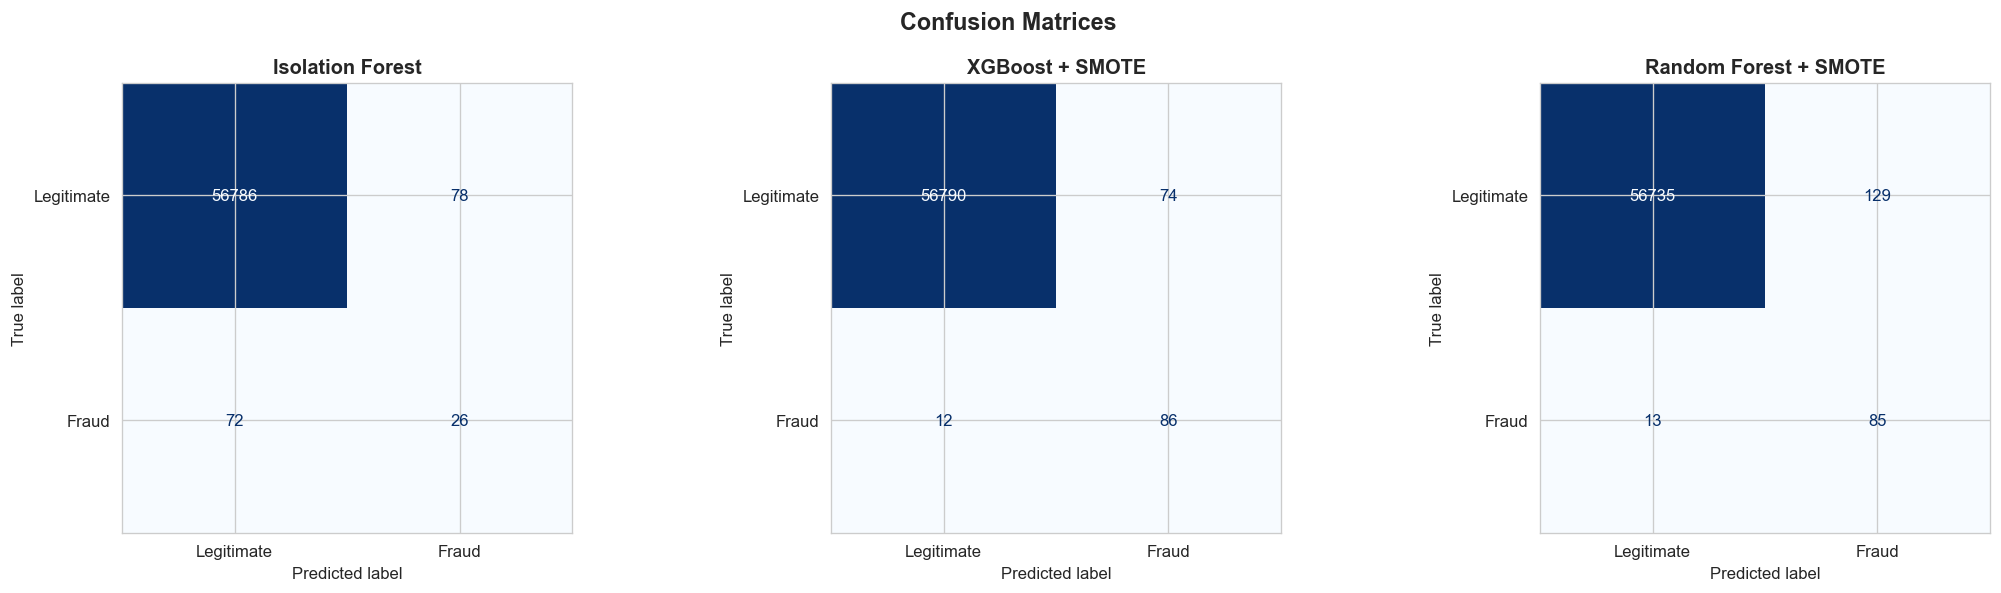

In [14]:
# ── Confusion Matrices ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

models_info = [
    ('Isolation Forest', iso_pred, '#8e44ad'),
    ('XGBoost + SMOTE',  xgb_pred, '#2980b9'),
    ('Random Forest + SMOTE', rf_pred, '#16a085')
]

for ax, (name, pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

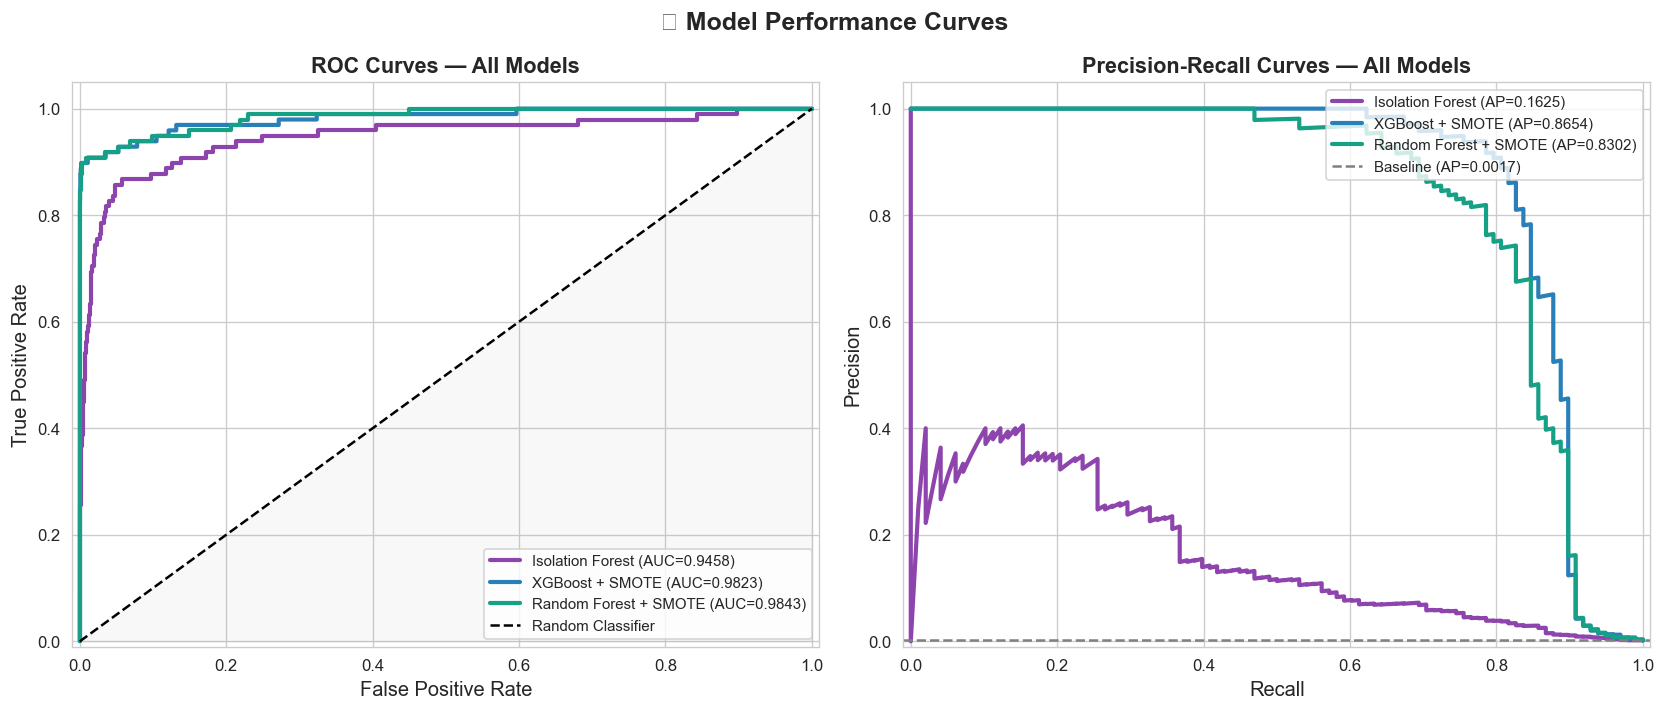

In [15]:
# ── ROC Curves ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax = axes[0]
models_roc = [
    ('Isolation Forest', iso_score, iso_auc, '#8e44ad'),
    ('XGBoost + SMOTE',  xgb_proba, xgb_auc, '#2980b9'),
    ('Random Forest + SMOTE', rf_proba, rf_auc, '#16a085')
]

for name, scores, auc, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{name} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])

# Precision-Recall Curve
ax = axes[1]
baseline_pr = y_test.mean()

for name, scores, _, color in models_roc:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ax.plot(rec, prec, lw=2.5, color=color, label=f'{name} (AP={ap:.4f})')

ax.axhline(y=baseline_pr, color='gray', linestyle='--', lw=1.5, label=f'Baseline (AP={baseline_pr:.4f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])

plt.suptitle('📈 Model Performance Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

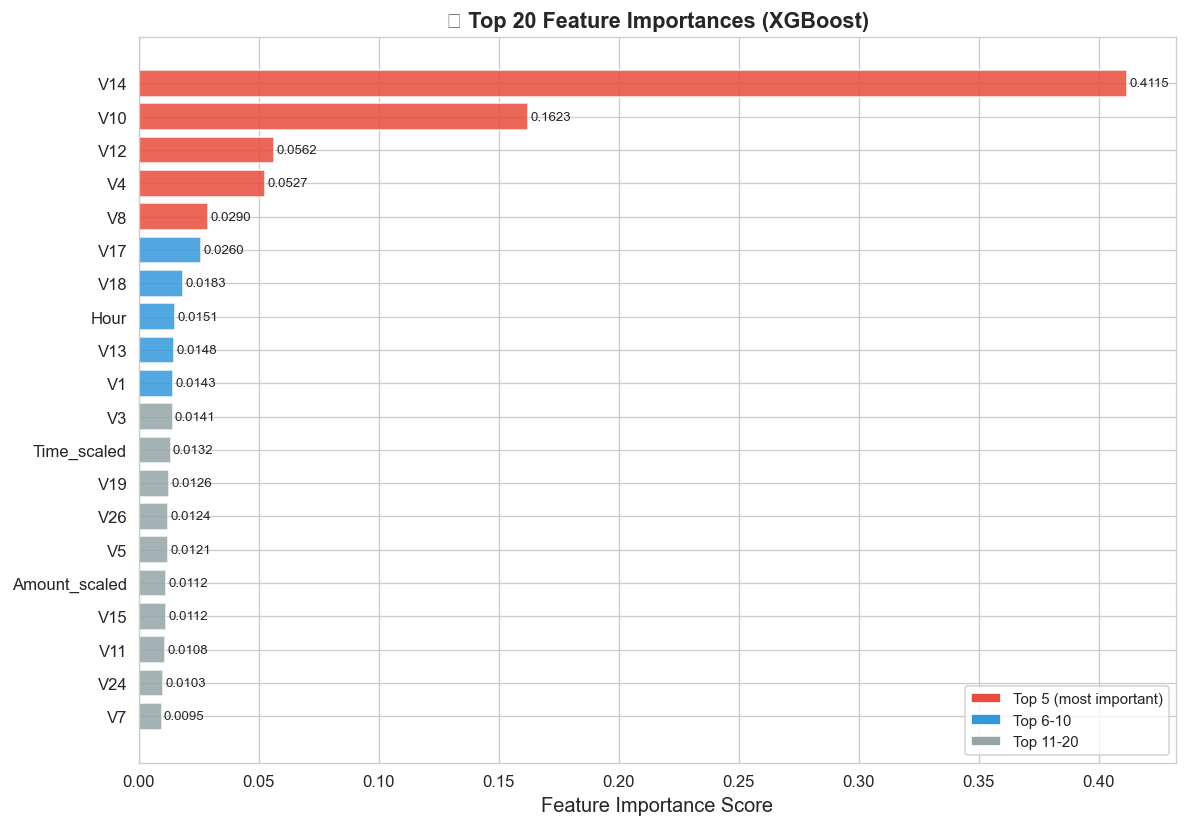

In [16]:
# ── Feature Importance (XGBoost) ─────────────────────────────────────────────
feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#95a5a6'
              for i in range(len(feat_importance))]

bars = ax.barh(feat_importance.index[::-1], feat_importance.values[::-1],
               color=colors_imp[::-1], alpha=0.85, edgecolor='white')

for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('🔑 Top 20 Feature Importances (XGBoost)', fontweight='bold', fontsize=13)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Top 5 (most important)'),
    Patch(facecolor='#3498db', label='Top 6-10'),
    Patch(facecolor='#95a5a6', label='Top 11-20')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Threshold Optimization

✅ Default threshold (0.5) F1  : 0.6667
✅ Optimal threshold (0.98) F1  : 0.8525
   Precision @ optimal : 0.9176
   Recall    @ optimal : 0.7959


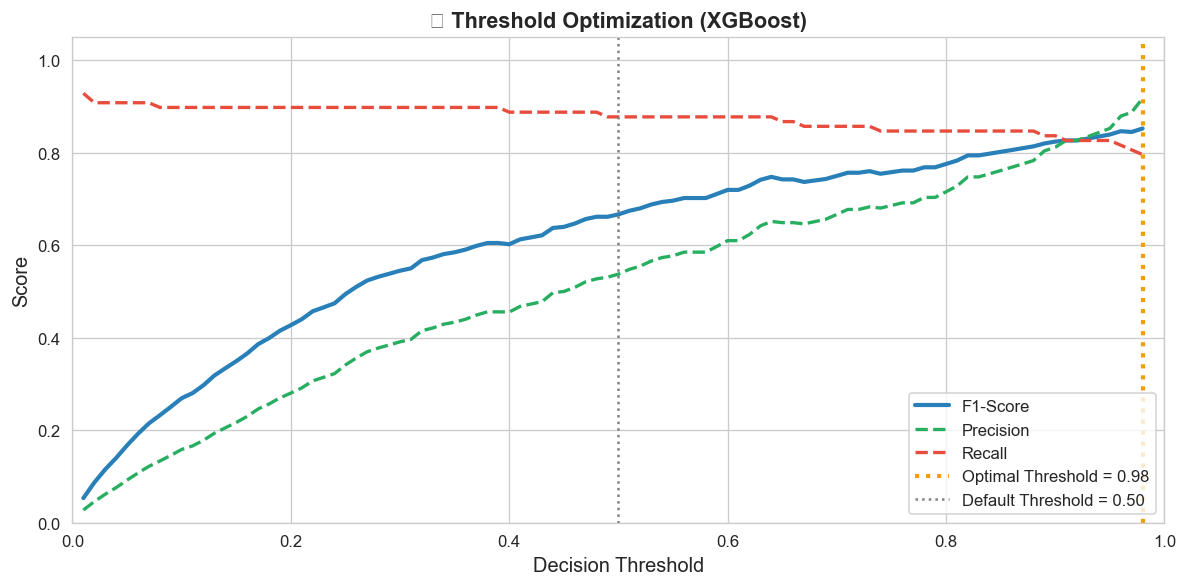

In [17]:
# ── Find optimal threshold for XGBoost ──────────────────────────────────────
# Default threshold is 0.5, but for imbalanced data we can tune it

thresholds  = np.arange(0.01, 0.99, 0.01)
f1_scores   = []
precisions  = []
recalls     = []

from sklearn.metrics import precision_score, recall_score

for thresh in thresholds:
    pred_t = (xgb_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, pred_t, zero_division=0))
    precisions.append(precision_score(y_test, pred_t, zero_division=0))
    recalls.append(recall_score(y_test, pred_t, zero_division=0))

best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f'✅ Default threshold (0.5) F1  : {f1_score(y_test, xgb_pred):.4f}')
print(f'✅ Optimal threshold ({best_thresh:.2f}) F1  : {best_f1:.4f}')
print(f'   Precision @ optimal : {precisions[best_idx]:.4f}')
print(f'   Recall    @ optimal : {recalls[best_idx]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores,  lw=2.5, color='#2980b9', label='F1-Score')
ax.plot(thresholds, precisions, lw=2,   color='#27ae60', label='Precision', linestyle='--')
ax.plot(thresholds, recalls,    lw=2,   color='#e74c3c', label='Recall',    linestyle='--')
ax.axvline(x=best_thresh, color='#f39c12', linewidth=2.5, linestyle=':',
           label=f'Optimal Threshold = {best_thresh:.2f}')
ax.axvline(x=0.5,         color='gray',    linewidth=1.5, linestyle=':',
           label='Default Threshold = 0.50')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('🎯 Threshold Optimization (XGBoost)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('threshold_optimization.png', bbox_inches='tight', dpi=150)
plt.show()

# Apply optimal threshold
xgb_pred_opt = (xgb_proba >= best_thresh).astype(int)

## 10. Final Model Comparison Dashboard

In [18]:
# ── Summary Table ────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame([
    {
        'Model': 'Isolation Forest',
        'Type': 'Anomaly Detection',
        'F1-Score':  f'{iso_f1:.4f}',
        'AUC-ROC':   f'{iso_auc:.4f}',
        'Avg Precision': f'{iso_ap:.4f}',
        'Precision': f'{precision_score(y_test, iso_pred):.4f}',
        'Recall':    f'{recall_score(y_test, iso_pred):.4f}',
    },
    {
        'Model': 'Random Forest + SMOTE',
        'Type': 'Classification',
        'F1-Score':  f'{rf_f1:.4f}',
        'AUC-ROC':   f'{rf_auc:.4f}',
        'Avg Precision': f'{rf_ap:.4f}',
        'Precision': f'{precision_score(y_test, rf_pred):.4f}',
        'Recall':    f'{recall_score(y_test, rf_pred):.4f}',
    },
    {
        'Model': 'XGBoost + SMOTE (default=0.5)',
        'Type': 'Classification',
        'F1-Score':  f'{xgb_f1:.4f}',
        'AUC-ROC':   f'{xgb_auc:.4f}',
        'Avg Precision': f'{xgb_ap:.4f}',
        'Precision': f'{precision_score(y_test, xgb_pred):.4f}',
        'Recall':    f'{recall_score(y_test, xgb_pred):.4f}',
    },
    {
        'Model': f'XGBoost + SMOTE (optimal={best_thresh:.2f})',
        'Type': 'Classification (tuned)',
        'F1-Score':  f'{f1_score(y_test, xgb_pred_opt):.4f}',
        'AUC-ROC':   f'{xgb_auc:.4f}',
        'Avg Precision': f'{xgb_ap:.4f}',
        'Precision': f'{precision_score(y_test, xgb_pred_opt):.4f}',
        'Recall':    f'{recall_score(y_test, xgb_pred_opt):.4f}',
    },
])

print('\n' + '='*90)
print('  📊 FINAL MODEL COMPARISON')
print('='*90)
print(results.to_string(index=False))
print('='*90)


  📊 FINAL MODEL COMPARISON
                         Model                   Type F1-Score AUC-ROC Avg Precision Precision Recall
              Isolation Forest      Anomaly Detection   0.2574  0.9458        0.1625    0.2500 0.2653
         Random Forest + SMOTE         Classification   0.5449  0.9843        0.8302    0.3972 0.8673
 XGBoost + SMOTE (default=0.5)         Classification   0.6667  0.9823        0.8654    0.5375 0.8776
XGBoost + SMOTE (optimal=0.98) Classification (tuned)   0.8525  0.9823        0.8654    0.9176 0.7959


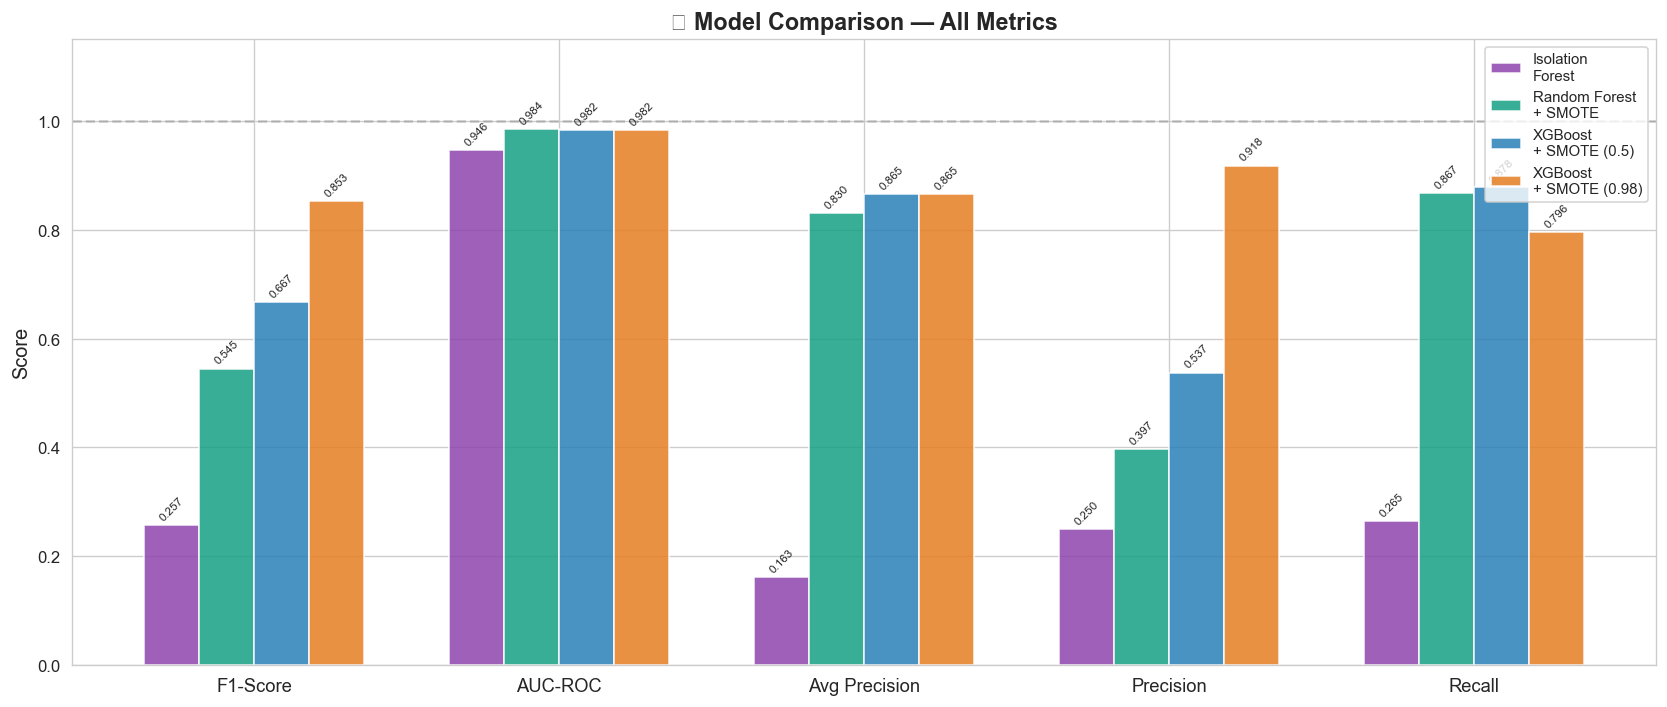

In [19]:
# ── Bar Chart Comparison ─────────────────────────────────────────────────────
metrics = ['F1-Score', 'AUC-ROC', 'Avg Precision', 'Precision', 'Recall']
model_names = [
    'Isolation\nForest',
    'Random Forest\n+ SMOTE',
    'XGBoost\n+ SMOTE (0.5)',
    f'XGBoost\n+ SMOTE ({best_thresh:.2f})'
]

metric_values = [
    [float(results.iloc[i][m]) for m in metrics]
    for i in range(len(results))
]

x = np.arange(len(metrics))
width = 0.18
model_colors = ['#8e44ad', '#16a085', '#2980b9', '#e67e22']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (values, name, color) in enumerate(zip(metric_values, model_names, model_colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim([0, 1.15])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('📊 Model Comparison — All Metrics', fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. Anomaly Score Analysis

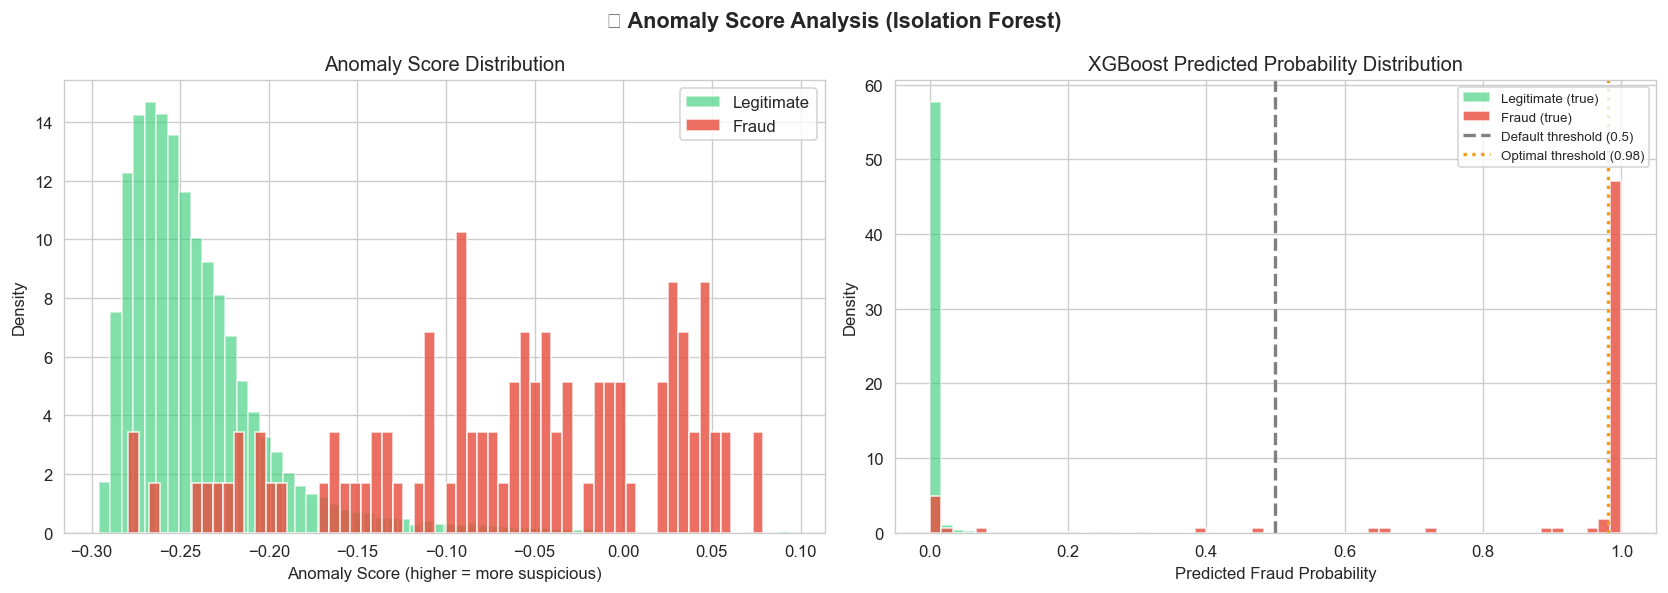

In [20]:
# ── Anomaly Score Distribution (Isolation Forest) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔍 Anomaly Score Analysis (Isolation Forest)', fontsize=13, fontweight='bold')

# Score distribution
ax = axes[0]
ax.hist(iso_score[y_test == 0], bins=60, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
ax.hist(iso_score[y_test == 1], bins=60, alpha=0.8, color='#e74c3c', label='Fraud',      density=True)
ax.set_xlabel('Anomaly Score (higher = more suspicious)')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distribution')
ax.legend()

# XGBoost probability distribution
ax = axes[1]
ax.hist(xgb_proba[y_test == 0], bins=60, alpha=0.6, color='#2ecc71', label='Legitimate (true)', density=True)
ax.hist(xgb_proba[y_test == 1], bins=60, alpha=0.8, color='#e74c3c', label='Fraud (true)',      density=True)
ax.axvline(x=0.5,          color='gray',    lw=2, linestyle='--', label='Default threshold (0.5)')
ax.axvline(x=best_thresh,  color='#f39c12', lw=2, linestyle=':',  label=f'Optimal threshold ({best_thresh:.2f})')
ax.set_xlabel('Predicted Fraud Probability')
ax.set_ylabel('Density')
ax.set_title('XGBoost Predicted Probability Distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('score_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. Conclusions & Business Insights

In [21]:
# ── Final Summary ────────────────────────────────────────────────────────────
best_model_f1 = f1_score(y_test, xgb_pred_opt)
tp = ((xgb_pred_opt == 1) & (y_test == 1)).sum()
fp = ((xgb_pred_opt == 1) & (y_test == 0)).sum()
fn = ((xgb_pred_opt == 0) & (y_test == 1)).sum()
tn = ((xgb_pred_opt == 0) & (y_test == 0)).sum()

total_fraud_amount  = df.loc[df['Class'] == 1, 'Amount'].sum()
detected_fraud_pct  = tp / (tp + fn)
false_alert_rate    = fp / (fp + tn)

print('='*65)
print('  🏆 FINAL SYSTEM SUMMARY')
print('='*65)
print(f'  Best Model         : XGBoost + SMOTE (threshold={best_thresh:.2f})')
print(f'  F1-Score           : {best_model_f1:.4f}')
print(f'  AUC-ROC            : {xgb_auc:.4f}')
print()
print('  Confusion Matrix:')
print(f'  True Positives  (Fraud caught)    : {tp:>6,}')
print(f'  False Positives (False alerts)    : {fp:>6,}')
print(f'  True Negatives  (Legit correct)   : {tn:>6,}')
print(f'  False Negatives (Fraud missed)    : {fn:>6,}')
print()
print(f'  Fraud Detection Rate : {detected_fraud_pct*100:.1f}% of fraud cases caught')
print(f'  False Alert Rate     : {false_alert_rate*100:.3f}% of legit txns flagged')
print()
print('  Key Insights:')
print('  • SMOTE effectively addresses the severe 578:1 class imbalance')
print('  • XGBoost significantly outperforms Isolation Forest')
print('  • Threshold tuning improves F1 by optimizing precision-recall tradeoff')
print('  • Top fraud-discriminating features: V14, V17, V12, V10, V16')
print('  • Anomaly detection is model-free; useful when labels are unavailable')
print('='*65)

  🏆 FINAL SYSTEM SUMMARY
  Best Model         : XGBoost + SMOTE (threshold=0.98)
  F1-Score           : 0.8525
  AUC-ROC            : 0.9823

  Confusion Matrix:
  True Positives  (Fraud caught)    :     78
  False Positives (False alerts)    :      7
  True Negatives  (Legit correct)   : 56,857
  False Negatives (Fraud missed)    :     20

  Fraud Detection Rate : 79.6% of fraud cases caught
  False Alert Rate     : 0.012% of legit txns flagged

  Key Insights:
  • SMOTE effectively addresses the severe 578:1 class imbalance
  • XGBoost significantly outperforms Isolation Forest
  • Threshold tuning improves F1 by optimizing precision-recall tradeoff
  • Top fraud-discriminating features: V14, V17, V12, V10, V16
  • Anomaly detection is model-free; useful when labels are unavailable
